In [1]:
import optuna
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import kpss

In [2]:
df=pd.read_csv("DATA/Backup/maize.csv")

df

,Date,price
0,2000-01-01 00:00:00,189.0
1,2000-02-01 00:00:00,188.3
2,2000-03-01 00:00:00,192.4
3,2000-04-01 00:00:00,191.2
4,2000-05-01 00:00:00,186.9
...,...,...
283,2023-08-01 00:00:00,186.9
284,2023-09-01 00:00:00,183.9
285,2023-10-01 00:00:00,183.5
286,2023-11-01 00:00:00,183.5


Missing values:
Date     0
price    0
dtype: int64

Duplicates:
0

Basic statistics of Price:
count    288.000000
mean     205.086111
std       47.012475
min      116.400000
25%      174.375000
50%      194.350000
75%      245.625000
max      321.100000
Name: price, dtype: float64


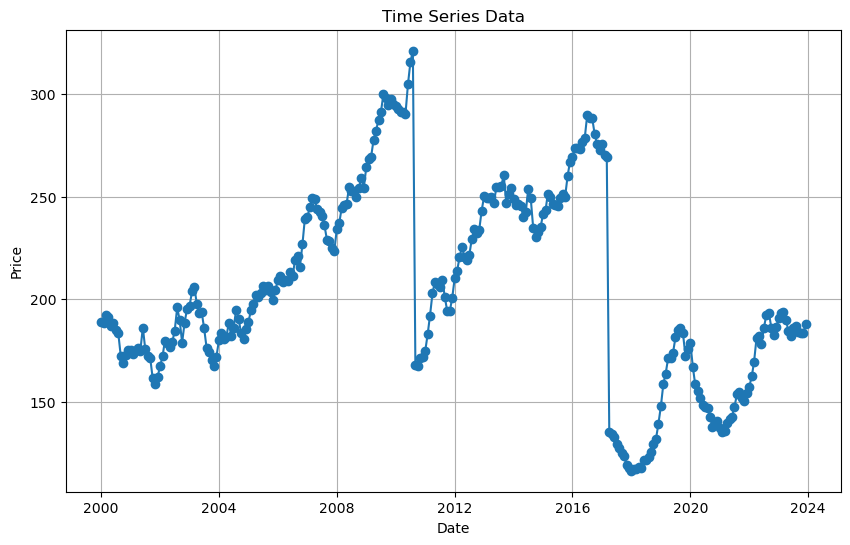

In [3]:
import pandas as pd


# Convert 'Date' column to datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicates:")
print(df.duplicated().sum())

# Check basic statistics of the 'Price' column
print("\nBasic statistics of Price:")
print(df['price'].describe())

# Plot the time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o')
plt.title('Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()


<Axes: >

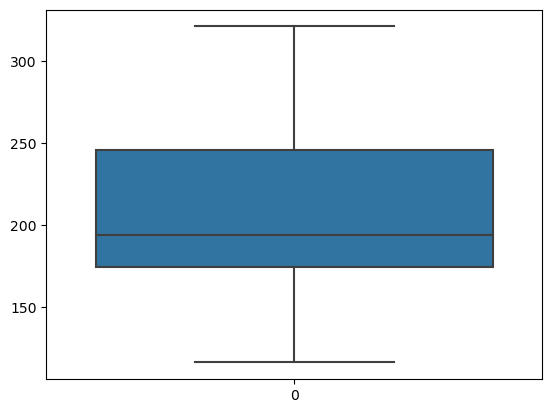

In [4]:
sn.boxplot(df['price'])

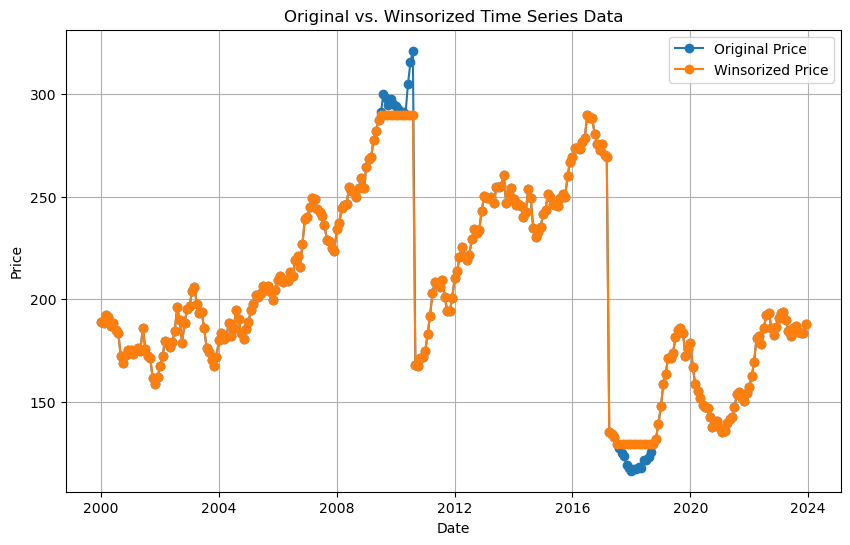

In [5]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values


# Winsorize the 'Price' column
#df['Price_winsorized'] = winsorize_outliers(df['price'])
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)


# Plot the original and winsorized time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o', label='Original Price')
plt.plot(df['Date'], df['price1'], marker='o', label='Winsorized Price')
plt.title('Original vs. Winsorized Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


In [13]:
'''from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decomposition
result = seasonal_decompose(df['price1'], model='additive', period=12)  # Assuming seasonality period of 12 months
detrended = df['price1'] - result.trend
seasonal = result.seasonal
residual = result.resid'''


"from statsmodels.tsa.seasonal import seasonal_decompose\n\n# Seasonal decomposition\nresult = seasonal_decompose(df['price1'], model='additive', period=12)  # Assuming seasonality period of 12 months\ndetrended = df['price1'] - result.trend\nseasonal = result.seasonal\nresidual = result.resid"

In [14]:
'''from sklearn.preprocessing import PowerTransformer

# Log transformation
df['Price_log'] = np.log(df['price1'])

# Box-Cox transformation
boxcox_transformer = PowerTransformer(method='box-cox')
df['Price_boxcox'] = boxcox_transformer.fit_transform(df['price1'].values.reshape(-1, 1))

# Quantile transformation (e.g., Gaussian transformation)
quantile_transformer = PowerTransformer(method='yeo-johnson')
df['Price_quantile'] = quantile_transformer.fit_transform(df['price1'].values.reshape(-1, 1))
'''

"from sklearn.preprocessing import PowerTransformer\n\n# Log transformation\ndf['Price_log'] = np.log(df['price1'])\n\n# Box-Cox transformation\nboxcox_transformer = PowerTransformer(method='box-cox')\ndf['Price_boxcox'] = boxcox_transformer.fit_transform(df['price1'].values.reshape(-1, 1))\n\n# Quantile transformation (e.g., Gaussian transformation)\nquantile_transformer = PowerTransformer(method='yeo-johnson')\ndf['Price_quantile'] = quantile_transformer.fit_transform(df['price1'].values.reshape(-1, 1))\n"

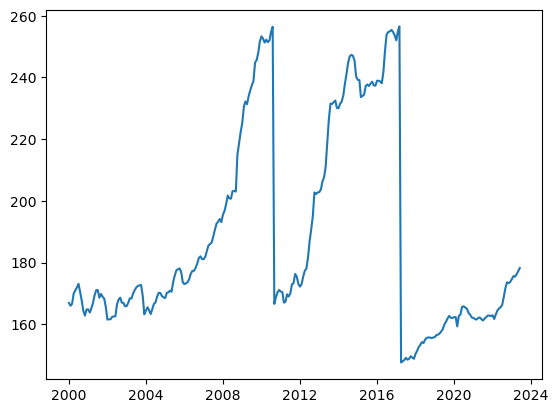

In [6]:
plt.plot(df['Date'],df['price'])

<Axes: >

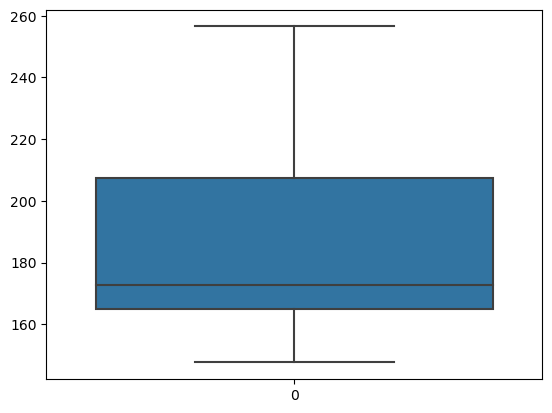

In [7]:
sn.boxplot(df['price'])

In [8]:
t=kpss(df['price'],'ct')
t

/var/folders/35/vcbg9sn9479dqrdl_3fgrrkh0000gn/T/ipykernel_85140/1514378212.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  t=kpss(df['price'],'ct')


(0.3404004465342978,
 0.01,
 10,
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

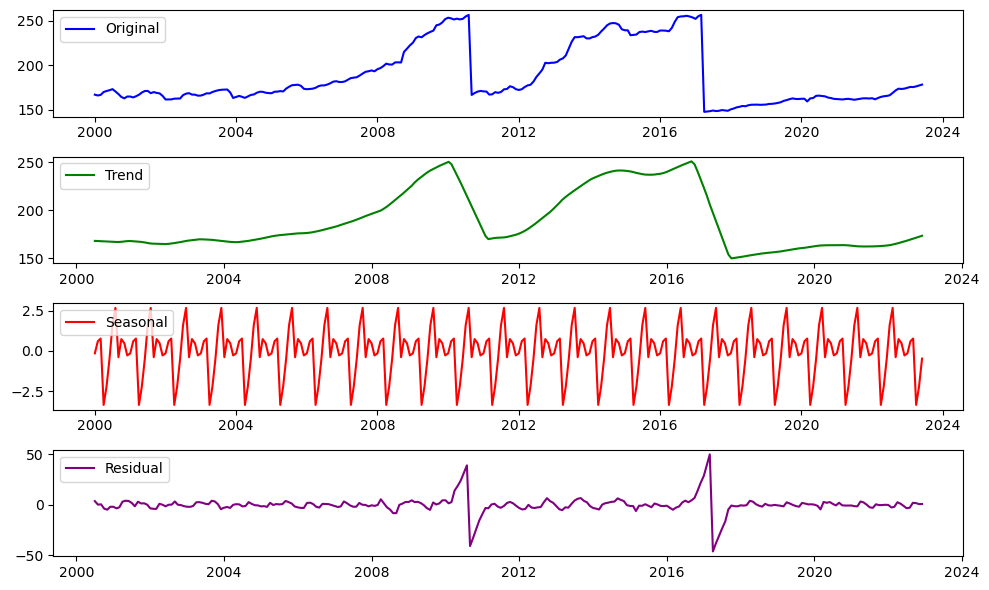

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming df is your DataFrame with a 'date' column and a 'value' column representing the time series
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['price'], model='additive')

# Plot the original time series
plt.figure(figsize=(10, 6))
plt.subplot(411)
plt.plot(df['price'], label='Original', color='blue')
plt.legend(loc='upper left')

# Plot the trend component
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='green')
plt.legend(loc='upper left')

# Plot the seasonal component
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='red')
plt.legend(loc='upper left')

# Plot the residual component
plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='purple')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [11]:
from scipy.stats import skew, kurtosis, shapiro

#df=pd.read_csv("DATA/Backup/rice.csv")

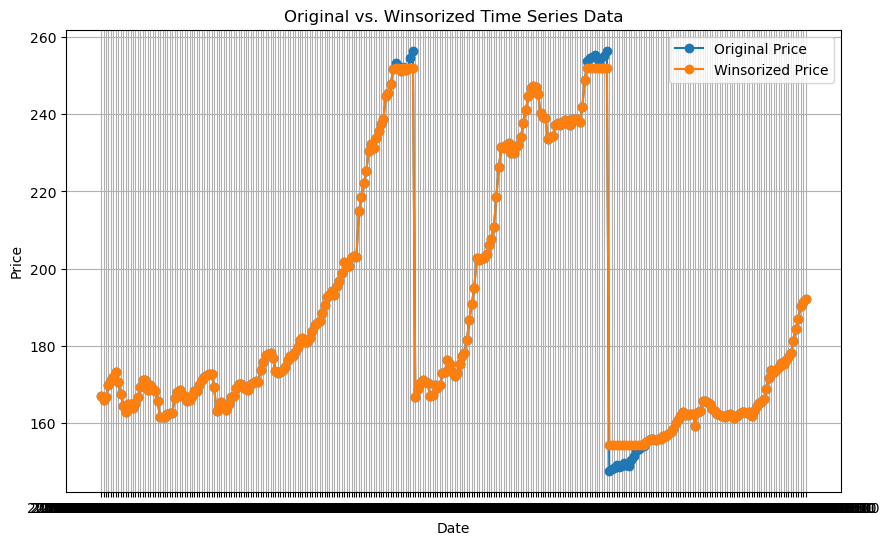

In [8]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values


# Winsorize the 'Price' column
#df['Price_winsorized'] = winsorize_outliers(df['price'])
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)


# Plot the original and winsorized time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o', label='Original Price')
plt.plot(df['Date'], df['price1'], marker='o', label='Winsorized Price')
plt.title('Original vs. Winsorized Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
df


,Date,price,price1
0,2000-01-01 00:00:00,166.9,166.9
1,2000-02-01 00:00:00,166.0,166.0
2,2000-03-01 00:00:00,166.6,166.6
3,2000-04-01 00:00:00,169.9,169.9
4,2000-05-01 00:00:00,171.0,171.0
...,...,...,...
283,2023-08-01 00:00:00,184.3,184.3
284,2023-09-01 00:00:00,187.0,187.0
285,2023-10-01 00:00:00,190.2,190.2
286,2023-11-01 00:00:00,191.4,191.4


In [106]:
#df.pop('price')
#df['price']=df.pop('price1')
df1=df
df1

,Date,price
0,2000-01-01 00:00:00,166.9
1,2000-02-01 00:00:00,166.0
2,2000-03-01 00:00:00,166.6
3,2000-04-01 00:00:00,169.9
4,2000-05-01 00:00:00,171.0
...,...,...
283,2023-08-01 00:00:00,184.3
284,2023-09-01 00:00:00,187.0
285,2023-10-01 00:00:00,190.2
286,2023-11-01 00:00:00,191.4


In [13]:
skewness = skew(df['price'])
kurt = kurtosis(df['price'])

# Perform Shapiro-Wilk test for normality
shapiro_stat, shapiro_p_value = shapiro(df['price'])

# Print the results
print("Skewness:", skewness)
print("Kurtosis:", kurt)
print("Shapiro-Wilk Statistic:", shapiro_stat)
print("Shapiro-Wilk p-value:", shapiro_p_value)

Skewness: 0.9062133854640201
Kurtosis: -0.6908483852913809
Shapiro-Wilk Statistic: 0.8249176740646362
Shapiro-Wilk p-value: 3.666893971553287e-17


In [14]:
# Convert 'date' column to datetime if it's not already
# Shift the 'price' column to create new columns

scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
#import matplotlib.pyplot as plt
#plt.plot(df['Date'],df['price'])


    

#dates_test, X_test, y_test = dates[q_80:], X[q_80:], y[q_80:]

#df['target-1'] = df['price'].shift(1)
#df['target-2'] = df['price'].shift(2)
#df['target-3'] = df['price'].shift(3)
#df['target-4'] = df['price'].shift(4)
#df['target-5'] = df['price'].shift(5)
#df['target-6'] = df['price'].shift(6)
#df['target-7'] = df['price'].shift(7)
#df['target-8'] = df['price'].shift(8)
#df['target-9'] = df['price'].shift(9)
#df['target-10'] = df['price'].shift(10)

In [10]:
#y

In [11]:
#dates
#X
#y

In [164]:
df=pd.read_csv("DATA/Backup/maize.csv")
scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
shift=3
for i in range(shift,0,-1):
    df['target-'+str(i)] = df['price'].shift(i)
d=df[shift:]

def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()
    dates = df_as_np[:, 0]
    middle_matrix = df_as_np[:, 2:]
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))
    Y = df_as_np[:, 1:2]
    return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(d)
dates.shape, X.shape, y.shape

q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)
dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

In [165]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras import layers
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

def objective(trial):
    # Define hyperparameters to tune
    #lstm_units = trial.suggest_int('lstm_units', 32, 256)
    #gru_units = trial.suggest_int('gru_units', 32, 256)
    num_filters = trial.suggest_int('num_filters', 16, 128)
    kernel_size = trial.suggest_int('kernel_size', 3, 7)
    dense_units = trial.suggest_int('dense_units', 16, 128)
    #num_lstm_layers = trial.suggest_int('num_lstm_layers', 1, 3)
    learning_rate = trial.suggest_categorical('learning_rate', [1e-5, 1e-4, 1e-3])

    # Construct the model
    model = Sequential([
        layers.Input((shift, 1)),
        #layers.LSTM(lstm_units),
        #layers.Bidirectional(layers.LSTM(lstm_units)),
        #layers.GRU(gru_units),
        layers.Conv1D(num_filters, kernel_size, activation='relu',padding='same'),
        layers.MaxPooling1D(),
        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dense(1)
    ])
    '''
    model = Sequential()
    model.add(layers.Input((shift, 1)))
    for _ in range(num_lstm_layers):
        model.add(layers.LSTM(lstm_units, return_sequences=True))
    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dense(1))'''
    
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    # Compile the model
    model.compile(loss='mse', 
                  optimizer=Adam(learning_rate=learning_rate),
                  metrics=['mean_absolute_error'])

    # Train the model
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200,callbacks=[early_stopping])

    # Evaluate the model on the validation set and return the validation loss
    loss = model.evaluate(X_val, y_val)[0]
    return loss


In [166]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)
best_params = study.best_params
print("Best hyperparameters:", best_params)


[I 2024-03-05 22:13:19,462] A new study created in memory with name: no-name-28efca35-0422-46ad-a1bf-606ef5abb8d6


Epoch 1/200
8/8 [==============================] - 0s 11ms/step - loss: 0.2606 - mean_absolute_error: 0.4580 - val_loss: 0.0402 - val_mean_absolute_error: 0.1832
Epoch 2/200
8/8 [==============================] - 0s 2ms/step - loss: 0.2491 - mean_absolute_error: 0.4468 - val_loss: 0.0374 - val_mean_absolute_error: 0.1757
Epoch 3/200
8/8 [==============================] - 0s 2ms/step - loss: 0.2376 - mean_absolute_error: 0.4359 - val_loss: 0.0346 - val_mean_absolute_error: 0.1683
Epoch 4/200
8/8 [==============================] - 0s 3ms/step - loss: 0.2267 - mean_absolute_error: 0.4250 - val_loss: 0.0320 - val_mean_absolute_error: 0.1610
Epoch 5/200
8/8 [==============================] - 0s 2ms/step - loss: 0.2159 - mean_absolute_error: 0.4140 - val_loss: 0.0296 - val_mean_absolute_error: 0.1542
Epoch 6/200
8/8 [==============================] - 0s 3ms/step - loss: 0.2051 - mean_absolute_error: 0.4031 - val_loss: 0.0274 - val_mean_absolute_error: 0.1476
Epoch 7/200
8/8 [================

[I 2024-03-05 22:13:20,698] Trial 0 finished with value: 0.002587666967883706 and parameters: {'num_filters': 53, 'kernel_size': 5, 'dense_units': 19, 'learning_rate': 0.0001}. Best is trial 0 with value: 0.002587666967883706.


Epoch 1/200
8/8 [==============================] - 0s 10ms/step - loss: 0.3117 - mean_absolute_error: 0.5022 - val_loss: 0.0448 - val_mean_absolute_error: 0.1931
Epoch 2/200
8/8 [==============================] - 0s 2ms/step - loss: 0.2774 - mean_absolute_error: 0.4720 - val_loss: 0.0377 - val_mean_absolute_error: 0.1752
Epoch 3/200
8/8 [==============================] - 0s 3ms/step - loss: 0.2470 - mean_absolute_error: 0.4434 - val_loss: 0.0313 - val_mean_absolute_error: 0.1576
Epoch 4/200
8/8 [==============================] - 0s 2ms/step - loss: 0.2186 - mean_absolute_error: 0.4150 - val_loss: 0.0255 - val_mean_absolute_error: 0.1397
Epoch 5/200
8/8 [==============================] - 0s 2ms/step - loss: 0.1920 - mean_absolute_error: 0.3876 - val_loss: 0.0204 - val_mean_absolute_error: 0.1221
Epoch 6/200
8/8 [==============================] - 0s 2ms/step - loss: 0.1671 - mean_absolute_error: 0.3603 - val_loss: 0.0158 - val_mean_absolute_error: 0.1042
Epoch 7/200
8/8 [================

[I 2024-03-05 22:13:21,433] Trial 1 finished with value: 0.002401296515017748 and parameters: {'num_filters': 99, 'kernel_size': 7, 'dense_units': 109, 'learning_rate': 0.0001}. Best is trial 1 with value: 0.002401296515017748.


...

[I 2024-03-05 22:16:51,831] Trial 98 finished with value: 0.0005404843832366168 and parameters: {'num_filters': 79, 'kernel_size': 5, 'dense_units': 108, 'learning_rate': 0.001}. Best is trial 84 with value: 0.000505490810610354.


Epoch 1/200
8/8 [==============================] - 0s 9ms/step - loss: 0.1692 - mean_absolute_error: 0.3541 - val_loss: 0.0024 - val_mean_absolute_error: 0.0422
Epoch 2/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0162 - mean_absolute_error: 0.0942 - val_loss: 0.0164 - val_mean_absolute_error: 0.1229
Epoch 3/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0209 - mean_absolute_error: 0.1103 - val_loss: 0.0098 - val_mean_absolute_error: 0.0921
Epoch 4/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0109 - mean_absolute_error: 0.0615 - val_loss: 0.0018 - val_mean_absolute_error: 0.0382
Epoch 5/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0100 - mean_absolute_error: 0.0666 - val_loss: 0.0034 - val_mean_absolute_error: 0.0503
Epoch 6/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0084 - mean_absolute_error: 0.0476 - val_loss: 0.0039 - val_mean_absolute_error: 0.0543
Epoch 7/200
8/8 [=================

Epoch 51/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0051 - mean_absolute_error: 0.0285 - val_loss: 6.2683e-04 - val_mean_absolute_error: 0.0193
Epoch 52/200
1/1 [==============================] - 0s 8ms/step - loss: 5.6300e-04 - mean_absolute_error: 0.0188


[I 2024-03-05 22:16:52,880] Trial 99 finished with value: 0.000563000445254147 and parameters: {'num_filters': 61, 'kernel_size': 5, 'dense_units': 124, 'learning_rate': 0.001}. Best is trial 84 with value: 0.000505490810610354.


Best hyperparameters: {'num_filters': 112, 'kernel_size': 5, 'dense_units': 124, 'learning_rate': 0.001}


In [168]:
best_params

{'num_filters': 112,
 'kernel_size': 5,
 'dense_units': 124,
 'learning_rate': 0.001}

In [188]:
#best_lstm_units = best_params['lstm_units']
#best_gru_units = best_params['gru_units']
num_filters = best_params['num_filters']
kernel_size = best_params['kernel_size']
best_dense_units = best_params['dense_units']
best_learning_rate = best_params['learning_rate']
#best_num_lstm_layers = best_params['num_lstm_layers']
model = Sequential([
    layers.Input((shift, 1)),
    #layers.LSTM(best_lstm_units),
    #layers.Bidirectional(layers.LSTM(best_lstm_units)),
    #layers.GRU(best_gru_units),
    layers.Conv1D(num_filters, kernel_size, activation='relu',padding='same'),
    layers.MaxPooling1D(),
    layers.Flatten(),
    layers.Dense(best_dense_units, activation='relu'),
    layers.Dense(1)
])
'''
model = Sequential()
model.add(layers.Input((shift, 1)))
for _ in range(2):
    model.add(layers.LSTM(best_lstm_units, return_sequences=True))
model.add(layers.Flatten())
model.add(layers.Dense(best_dense_units, activation='relu'))
model.add(layers.Dense(1))'''


# Compile the final model
model.compile(loss='mse', 
                optimizer=Adam(learning_rate=best_learning_rate),
                metrics=['mean_absolute_error'])

# Train the final model on the entire training data
h=model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200)
    

Epoch 1/200
8/8 [==============================] - 0s 10ms/step - loss: 0.1403 - mean_absolute_error: 0.3301 - val_loss: 0.0036 - val_mean_absolute_error: 0.0420
Epoch 2/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0234 - mean_absolute_error: 0.1206 - val_loss: 0.0096 - val_mean_absolute_error: 0.0922
Epoch 3/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0141 - mean_absolute_error: 0.0833 - val_loss: 0.0079 - val_mean_absolute_error: 0.0825
Epoch 4/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0083 - mean_absolute_error: 0.0529 - val_loss: 0.0011 - val_mean_absolute_error: 0.0285
Epoch 5/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0081 - mean_absolute_error: 0.0544 - val_loss: 0.0031 - val_mean_absolute_error: 0.0481
Epoch 6/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0070 - mean_absolute_error: 0.0401 - val_loss: 0.0011 - val_mean_absolute_error: 0.0278
Epoch 7/200
8/8 [================

Epoch 51/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0054 - mean_absolute_error: 0.0391 - val_loss: 6.7779e-04 - val_mean_absolute_error: 0.0204
Epoch 52/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0051 - mean_absolute_error: 0.0302 - val_loss: 8.2119e-04 - val_mean_absolute_error: 0.0211
Epoch 53/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0049 - mean_absolute_error: 0.0319 - val_loss: 6.8408e-04 - val_mean_absolute_error: 0.0198
Epoch 54/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0052 - mean_absolute_error: 0.0300 - val_loss: 7.8504e-04 - val_mean_absolute_error: 0.0209
Epoch 55/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0052 - mean_absolute_error: 0.0357 - val_loss: 8.0466e-04 - val_mean_absolute_error: 0.0213
Epoch 56/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0049 - mean_absolute_error: 0.0292 - val_loss: 0.0010 - val_mean_absolute_error: 0.0248
Epoch 57

8/8 [==============================] - 0s 2ms/step - loss: 0.0048 - mean_absolute_error: 0.0294 - val_loss: 8.3876e-04 - val_mean_absolute_error: 0.0221
Epoch 150/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0049 - mean_absolute_error: 0.0304 - val_loss: 6.0769e-04 - val_mean_absolute_error: 0.0189
Epoch 151/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0048 - mean_absolute_error: 0.0286 - val_loss: 6.0327e-04 - val_mean_absolute_error: 0.0190
Epoch 152/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0049 - mean_absolute_error: 0.0311 - val_loss: 0.0010 - val_mean_absolute_error: 0.0254
Epoch 153/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0049 - mean_absolute_error: 0.0308 - val_loss: 7.6856e-04 - val_mean_absolute_error: 0.0212
Epoch 154/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0051 - mean_absolute_error: 0.0294 - val_loss: 5.5257e-04 - val_mean_absolute_error: 0.0184
Epoch 155/200
8/

Training Loss: [0.0046949624083936214, 0.028580669313669205]
Testing Loss: [0.00046387803740799427, 0.017828384414315224]


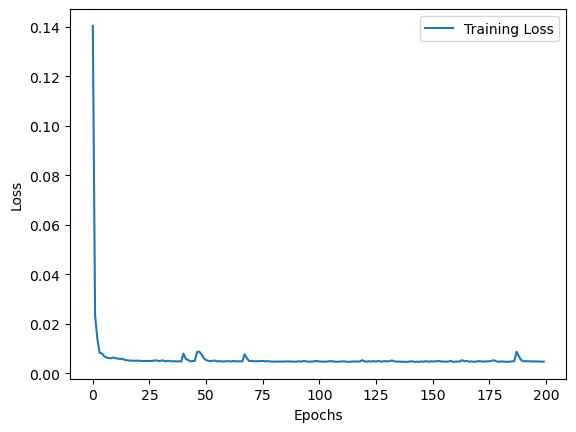

In [189]:
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training Loss: {train_loss}')
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing Loss: {test_loss}')

plt.plot(h.history['loss'], label='Training Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

8/8 [==============================] - 0s 467us/step


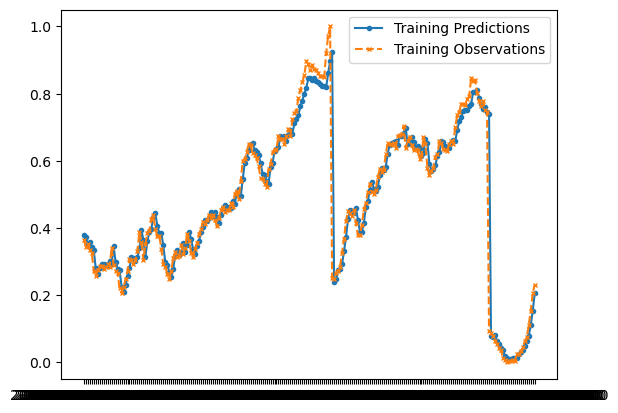

In [190]:
train_predictions = model.predict(X_train)

plt.plot(dates_train, train_predictions,linestyle="-", marker='o', markersize=3)
plt.plot(dates_train, y_train, linestyle="--", marker='x', markersize=3)

##plt.plot(train_predictions)
##plt.plot(y_train)
plt.legend(['Training Predictions', 'Training Observations'])

1/1 [==============================] - 0s 12ms/step


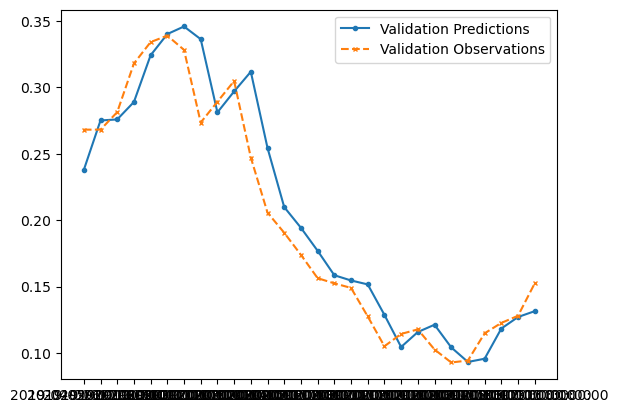

In [191]:
val_predictions = model.predict(X_val)#.flatten()

plt.plot(dates_val, val_predictions,linestyle="-", marker='o', markersize=3)
plt.plot(dates_val, y_val,linestyle="--", marker='x', markersize=3)
plt.legend(['Validation Predictions', 'Validation Observations'])

1/1 [==============================] - 0s 10ms/step


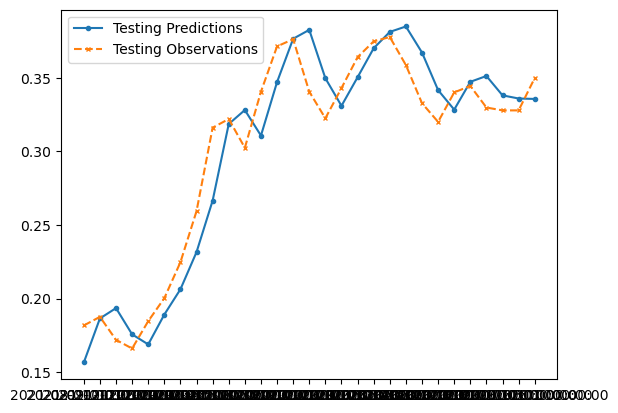

In [192]:
test_predictions = model.predict(X_test)#.flatten()

plt.plot(dates_test, test_predictions,linestyle="-", marker='o', markersize=3)
plt.plot(dates_test, y_test,linestyle="--", marker='x', markersize=3)
plt.legend(['Testing Predictions', 'Testing Observations'])

In [142]:
#test_predictions

In [193]:
# Inverse transform to get actual prices
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_pred_actual = scaler.inverse_transform(train_predictions.reshape(-1,1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))
y_val_pred_actual = scaler.inverse_transform(val_predictions.reshape(-1,1))
y_val_actual = scaler.inverse_transform(y_val.reshape(-1,1))


In [194]:
# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train_actual, y_train_pred_actual)
train_mse = mean_squared_error(y_train_actual, y_train_pred_actual)
val_mae = mean_absolute_error(y_val_actual, y_val_pred_actual)
test_mae = mean_absolute_error(y_test_actual, y_test_pred_actual)
test_mse = mean_squared_error(y_test_actual, y_test_pred_actual)
val_mse = mean_squared_error(y_val_actual, y_val_pred_actual)

print(f'Training MAE: {train_mae}')
print(f'Training MSE: {train_mse}')
print(f'Val MAE: {val_mae}')
print(f'Val MSE: {val_mse}')
print(f'Testing MAE: {test_mae}')
print(f'Testing MSE: {test_mse}')


train_r = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, y_train_pred_actual)
test_r = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_test_pred_actual)
val_r = np.sqrt(val_mse)
val_r2 = r2_score(y_val_actual, y_val_pred_actual)


print(train_r)
print(train_r2)
print(val_r)
print(val_r2)
print(test_r)
print(test_r2)

Training MAE: 5.850461006164551
Training MSE: 196.72869873046875
Val MAE: 3.6588244438171387
Val MSE: 24.987548828125
Testing MAE: 3.6494715213775635
Testing MSE: 19.437480926513672
14.026001
0.912585681588982
4.9987545
0.9160737748311767
4.408796
0.9023198752822621


In [195]:
model.save('maize_cnn')

INFO:tensorflow:Assets written to: maize_cnn/assets


INFO:tensorflow:Assets written to: maize_cnn/assets


In [196]:
import tensorflow as tf
m1=tf.keras.models.load_model('maize_cnn')
m1.layers[0].input_shape

(None, 3, 1)

In [197]:
test_predictions = m1.predict(X_test)#.flatten()

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))

test_r2 = r2_score(y_test_actual, y_test_pred_actual)
print(test_r2)
#plt.plot(dates_test, test_predictions)
#plt.plot(dates_test, y_test)
#plt.legend(['Testing Predictions', 'Testing Observations'])

1/1 [==============================] - 0s 34ms/step
0.9023198752822621


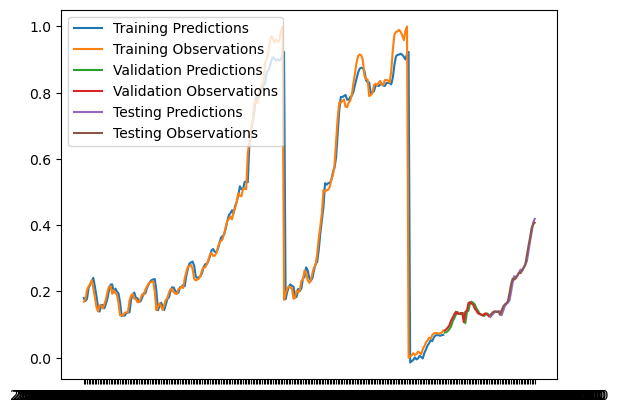

In [150]:
plt.plot(figsize=(100,100))
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations'],loc='upper left')



In [81]:
n = 12  # Change this value to forecast more or fewer values
forecast = []
last_data = X[-1]  # Last X data point
for i in range(n):
    next_y = model.predict(last_data.reshape(1, X.shape[1], X.shape[2]))  # Predict next y
    forecast.append(next_y)
    last_data = np.append(last_data[1:], next_y)  # Shift data by 1 and append next_y
forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))
y_act=scaler.inverse_transform(np.array(y).reshape(-1, 1))

1/1 [==============================] - 0s 9ms/step


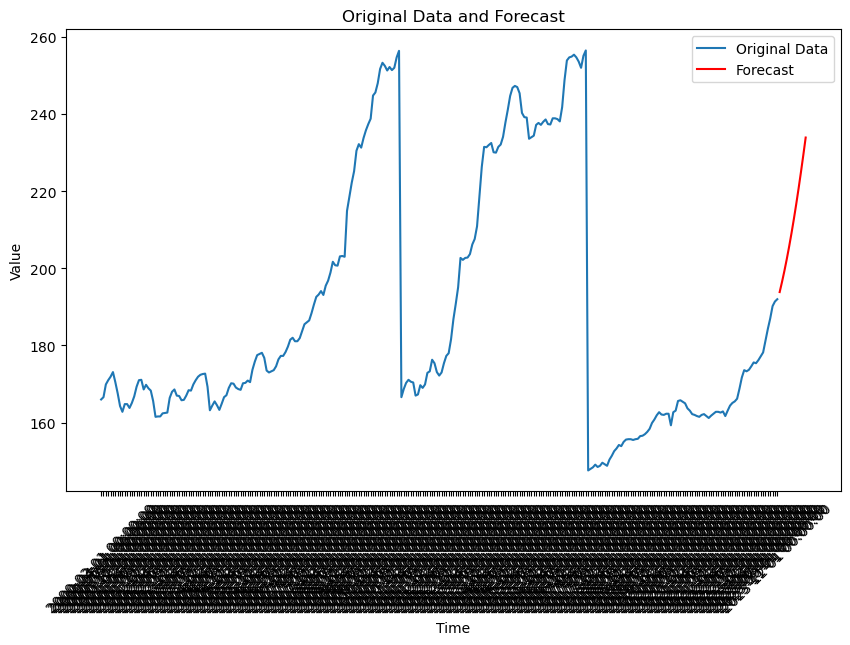

In [82]:
plt.figure(figsize=(10, 6))
plt.plot(dates, y_act, label='Original Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data and Forecast')
plt.xticks(rotation=45)
plt.legend()

# Plot forecast
forecast_dates = np.arange(len(y), len(y) + n)
plt.plot(forecast_dates, forecast, label='Forecast', color='red')
plt.legend()

plt.show()